In [ ]:
import pandas as pd
import re

def parse_webanno_for_classification(file_path):
    """Parse WebAnno TSV 3.3 format for sentence classification."""
    data = []

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    blocks = content.split('\n\n')

    for block in blocks:
        if not block.strip():
            continue

        lines = block.strip().split('\n')
        sentence_text = None
        macro_category = None

        for line in lines:
            if line.startswith('#Text='):
                sentence_text = line.replace('#Text=', '').strip()

            elif '\t' in line and not line.startswith('#'):
                parts = line.split('\t')
                if len(parts) >= 5 and parts[4] != '_' and parts[4].strip():
                    label = parts[4].strip()
                    match = re.match(r'([A-Za-z]+)', label)
                    if match:
                        macro_category = match.group(1)
                        break

        if sentence_text and macro_category and sentence_text != "Sentence":
            data.append({'text': sentence_text, 'label': macro_category})

    return pd.DataFrame(data)

df_train = parse_webanno_for_classification("SPEDAC2_TRAIN.tsv")
df_train.head()

,text,label
0,I'm six years survivor of this cancer after ch...,SpecialData
1,"""I tried a number of different remedies such a...",SpecialData
2,"""Because of being on a disability pension , I ...",SpecialData
3,"""For some reason, they brought a lot of cavies...",SpecialData
4,"""I am on 75mg, twice a day, tablet form My doc...",SpecialData


In [ ]:
df_train.describe()

,text,label
count,3710,3710
unique,3699,5
top,Einarr was only a few inches taller than I am ...,SpecialData
freq,2,979


In [ ]:
# parse - validation and test data
def parse_webanno_tsv(filepath):
    sentences_train = []
    current_tokens = []
    current_label = None
    current_text = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')

            # Skip header and empty lines
            if line.startswith('#FORMAT') or line.startswith('#T_SP'):
                continue

            # Sentence text line
            if line.startswith('#Text='):
                current_text = line[6:]
                continue

            # Empty line = end of sentence
            if line == '':
                if current_tokens and current_label and current_text:
                    sentences_train.append({
                        'text':  current_text,
                        'label': current_label
                    })
                current_tokens = []
                current_label  = None
                current_text   = None
                continue

            # Token line
            parts = line.split('\t')
            if len(parts) >= 4:
                token = parts[2]
                label_raw = parts[3]  # e.g. "Non-sensitive[1]" or "Sensitive[1]" or "_"

                if label_raw != '_':
                    # Strip the sentence ID number in brackets
                    import re
                    label = re.sub(r'\[\d+\]', '', label_raw)  # "Non-sensitive" or "Sensitive"
                    current_label = label
                current_tokens.append(token)

    return sentences_train

sentences_vali = parse_webanno_tsv('SPEDAC2_VALI.tsv')
sentences_test = parse_webanno_tsv('SPEDAC2_TEST.tsv')
# Result: [{'text': 'Coffee scrub helps...', 'label': 'Non-sensitive'}, ...]

#training dataframe
import pandas as pd
df_vali = pd.DataFrame(sentences_vali)
df_test = pd.DataFrame(sentences_test)


In [ ]:
df_train.info()
df_train['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3710 entries, 0 to 3709
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3710 non-null   object
 1   label   3710 non-null   object
dtypes: object(2)
memory usage: 58.1+ KB


,count
label,
SpecialData,979
Internal,870
External,841
Social,552
Financial,468


In [ ]:
df_vali.describe()
df_vali['label'].value_counts()

,count
label,
Social,137
SpecialData,103
External,81
Financial&Tracking,59
Internal,30


In [ ]:
df_test.describe()
df_test['label'].value_counts()


,count
label,
Social,328
SpecialData,274
External,219
Financial&Tracking,122
Internal,83


In [ ]:
#combine all sets into one
import pandas as pd

combined_df_raw = pd.concat([df_train, df_vali, df_test], axis=0, ignore_index=True)
print("Before merging the labels")
combined_df_raw["label"].value_counts()



Before merging the labels


,count
label,
SpecialData,1356
External,1141
Social,1017
Internal,983
Financial,468
Financial&Tracking,181


In [ ]:
# REPLACE Financial&Tracking WITH Financial
combined_df_raw["label"] = combined_df_raw["label"].replace("Financial&Tracking", "Financial")
print("\nAfter merging the labels")
combined_df_raw["label"].value_counts()


After merging the labels


,count
label,
SpecialData,1356
External,1141
Social,1017
Internal,983
Financial,649


**DEDUPLICATE**

In [ ]:
import pandas as pd

# Always deduplicate before splitting
combined_df = combined_df_raw.drop_duplicates(subset='text', keep='first')
print("Test data deduplicated:")

combined_df.to_csv("combined_dataset.csv", index=False)
#shuffle
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
combined_df['label'].value_counts()


Test data deduplicated:


,count
label,
SpecialData,1356
External,1130
Social,1008
Internal,982
Financial,649


**DATA EXPLORATION**

In [ ]:
def class_distribution(df, name):
    counts = df['label'].value_counts()
    percentages = df['label'].value_counts(normalize=True) * 100

    report = pd.DataFrame({
        'count': counts,
        'percentage': percentages.round(2)
    })

    print(f"\nClass Distribution - {name}")
    print(report)

class_distribution(train_df, "Train")
class_distribution(val_df, "Validation")
class_distribution(test_df, "Test")


train_df['sentence_length'] = train_df['text'].str.split().apply(len)
val_df['sentence_length']   = val_df['text'].str.split().apply(len)
test_df['sentence_length']  = test_df['text'].str.split().apply(len)

print(train_df['sentence_length'].describe())

import matplotlib.pyplot as plt

plt.figure()
plt.hist(train_df['sentence_length'], bins=50)
plt.title("Sentence Length Distribution - Train")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(val_df['sentence_length'], bins=50)
plt.title("Sentence Length Distribution - Validation")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(test_df['sentence_length'], bins=50)
plt.title("Sentence Length Distribution - Test")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode labels
le = LabelEncoder()
combined_df["label_encoded"] = le.fit_transform(combined_df["label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

X = combined_df["text"]
y = combined_df["label_encoded"]
print(combined_df["label_encoded"].value_counts())


{'External': np.int64(0), 'Financial': np.int64(1), 'Internal': np.int64(2), 'Social': np.int64(3), 'SpecialData': np.int64(4)}
label_encoded
4    1356
0    1130
3    1008
2     982
1     649
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=5   # removes very rare words
)

X_tfidf = vectorizer.fit_transform(X)


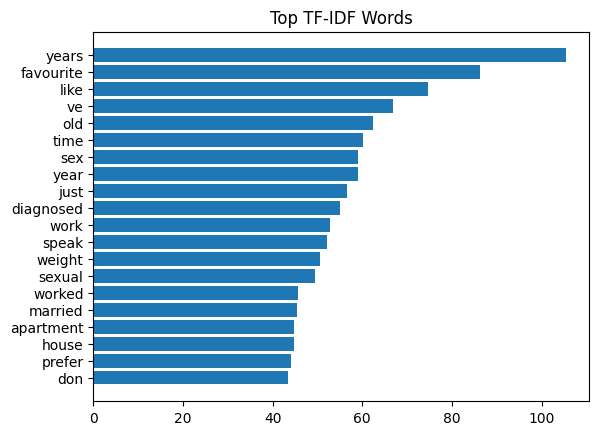

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
tfidf_sum = np.asarray(X_tfidf.sum(axis=0)).flatten()

top_indices = tfidf_sum.argsort()[-20:]
top_words = feature_names[top_indices]
top_scores = tfidf_sum[top_indices]

plt.barh(top_words, top_scores)
plt.title("Top TF-IDF Words")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print(y_test.value_counts())

Train size: 3587
Test size: 1538
label_encoded
4    407
0    339
3    302
2    295
1    195
Name: count, dtype: int64


**LOGISTIC REGRESSION WITHOUT CROSS VALIDATION**

              precision    recall  f1-score   support

           0       0.91      0.86      0.88       339
           1       0.96      0.84      0.90       195
           2       0.74      0.53      0.62       295
           3       0.59      0.74      0.65       302
           4       0.86      0.95      0.90       407

    accuracy                           0.79      1538
   macro avg       0.81      0.78      0.79      1538
weighted avg       0.80      0.79      0.79      1538



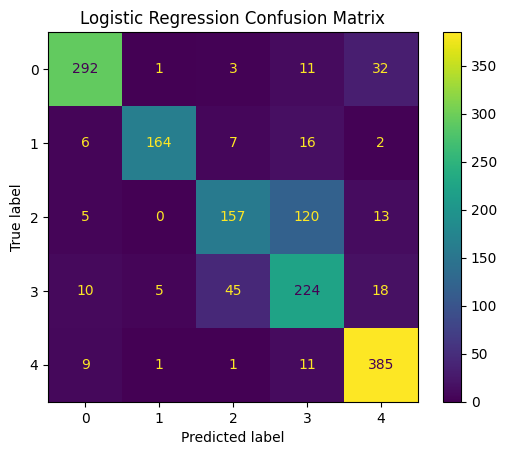

F1 Macro: 0.7902497547882528


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print("F1 Macro:", f1_score(y_test, y_pred, average="macro"))

**LOGISTIC REGRESSION WITH CROSS VALIDATION AND REGULARISATION**

Fitting LogisticRegressionCV...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.2s finished



Best C values per class: [2.7825594 2.7825594 2.7825594 2.7825594 2.7825594]
Number of iterations: [[[10  1  3 11 16 56 54 44  0  0]
  [10  1  3  9 23 55 63 40  0  0]
  [10  1  3 11 24 43 81 28  0  0]
  [10  1  3  9 22 47 68 53  0  0]
  [10  1  3 10 17 51 53 29  0  0]]]

CV scores shape: (5, 10)
Mean CV scores for each C: [0.52976439 0.52990539 0.52195678 0.53865498 0.53422338]
Best mean CV score: 0.5387

LOGISTIC REGRESSION CV - TEST SET RESULTS
              precision    recall  f1-score   support

    External       0.90      0.90      0.90       339
   Financial       0.95      0.85      0.90       195
    Internal       0.70      0.55      0.62       295
      Social       0.58      0.72      0.64       302
 SpecialData       0.90      0.92      0.91       407

    accuracy                           0.80      1538
   macro avg       0.81      0.79      0.79      1538
weighted avg       0.81      0.80      0.80      1538



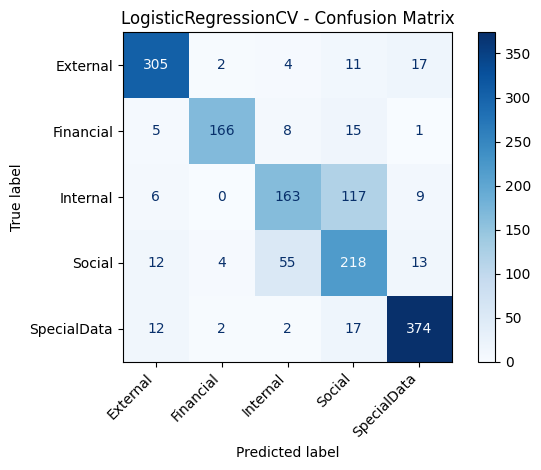


Test F1 Macro: 0.7938

COMPARISON: Regular LR vs CV
Regular LR Test F1: 0.7902
CV LR Test F1:      0.7938


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Define regularization strengths to try (C values)
# Smaller C = stronger regularization, larger C = weaker regularization
Cs = np.logspace(-4, 4, 10)  # 10 values from 0.0001 to 10000

# Create LogisticRegressionCV model
model_cv = LogisticRegressionCV(
    Cs=Cs,                    # Range of regularization parameters to try
    cv=5,                     # 5-fold cross-validation
    scoring='f1_macro',       # Use macro F1 score for optimization
    max_iter=1000,            # Maximum iterations
    random_state=42,          # For reproducibility
    n_jobs=-1,                # Use all CPU cores
    verbose=1                 # Show progress
)

# Fit the model (CV happens automatically)
print("Fitting LogisticRegressionCV...")
model_cv.fit(X_train, y_train)

# Check which C value was selected
print(f"\nBest C values per class: {model_cv.C_}")
print(f"Number of iterations: {model_cv.n_iter_}")

# Get cross-validation scores for the best C
print(f"\nCV scores shape: {model_cv.scores_[1].shape}")  # scores_[class][C_index][fold]
mean_scores = model_cv.scores_[1].mean(axis=1)  # Average across folds for class 1
print(f"Mean CV scores for each C: {mean_scores}")
print(f"Best mean CV score: {mean_scores.max():.4f}")

# Predict on test set
y_pred_cv = model_cv.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("LOGISTIC REGRESSION CV - TEST SET RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_cv, target_names=le.classes_))

# Confusion Matrix
cm_cv = confusion_matrix(y_test, y_pred_cv)
disp = ConfusionMatrixDisplay(cm_cv, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("LogisticRegressionCV - Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# F1 Score
f1_cv = f1_score(y_test, y_pred_cv, average="macro")
print(f"\nTest F1 Macro: {f1_cv:.4f}")

# Compare with regular Logistic Regression
print("\n" + "="*50)
print("COMPARISON: Regular LR vs CV")
print("="*50)
print(f"Regular LR Test F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"CV LR Test F1:      {f1_cv:.4f}")

Fitting KNN with GridSearchCV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters: {'metric': 'cosine', 'n_neighbors': 30, 'weights': 'distance'}
Best CV Score (F1 Macro): 0.7614

Top 5 Parameter Combinations:
                                                        params  mean_test_score  std_test_score
{'metric': 'cosine', 'n_neighbors': 30, 'weights': 'distance'}         0.761418        0.011925
{'metric': 'cosine', 'n_neighbors': 25, 'weights': 'distance'}         0.755397        0.017274
 {'metric': 'cosine', 'n_neighbors': 30, 'weights': 'uniform'}         0.754586        0.013908
{'metric': 'cosine', 'n_neighbors': 20, 'weights': 'distance'}         0.750701        0.012974
 {'metric': 'cosine', 'n_neighbors': 20, 'weights': 'uniform'}         0.749877        0.015923

KNN WITH CROSS-VALIDATION - TEST SET RESULTS
              precision    recall  f1-score   support

    External       0.86      0.85      0.85       339
   Financial       0.92      

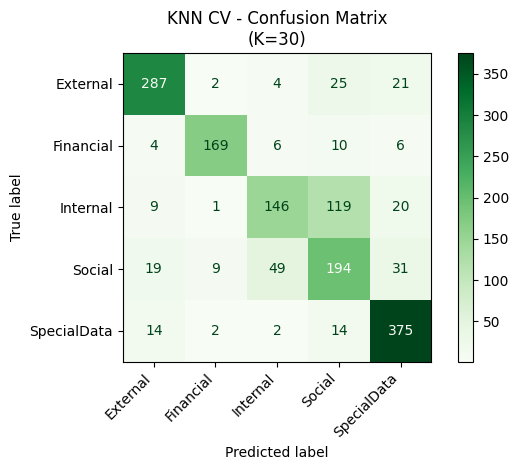


Test F1 Macro: 0.7573


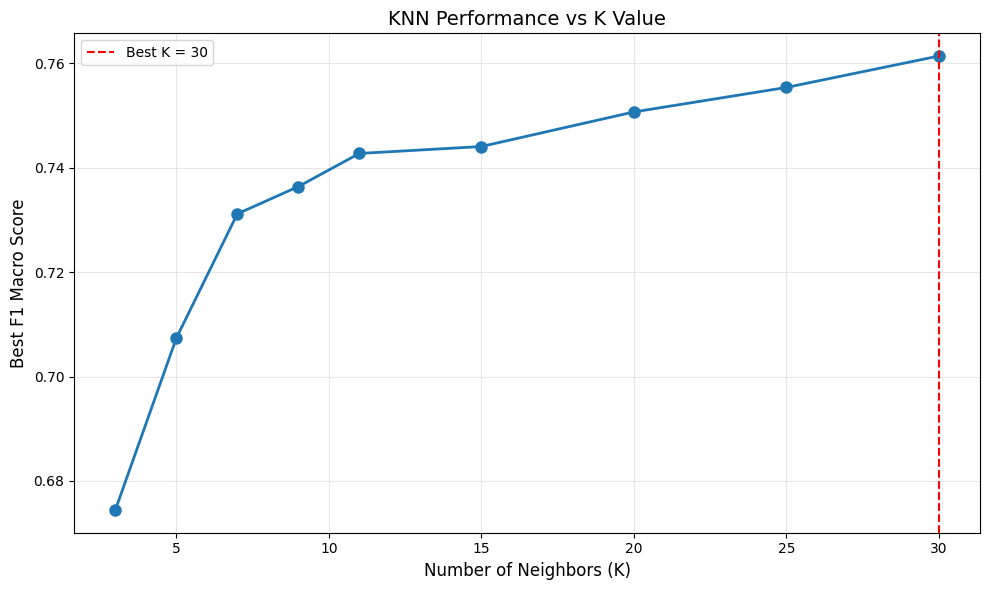


COMPARISON: All Models
Logistic Regression CV Test F1: 0.7938
KNN CV Test F1:                  0.7573


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Define parameter grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 30],  # Different K values to try
    'weights': ['uniform', 'distance'],                # Weighting scheme
    'metric': ['euclidean', 'manhattan', 'cosine']     # Distance metrics
}

# Create base KNN model
knn_base = KNeighborsClassifier()

# Create GridSearchCV (this does cross-validation automatically)
knn_cv = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring='f1_macro',        # Use macro F1 score for optimization
    n_jobs=-1,                 # Use all CPU cores
    verbose=2,                 # Show progress
    return_train_score=True    # Also return training scores
)

# Fit the model (CV happens automatically)
print("Fitting KNN with GridSearchCV...")
knn_cv.fit(X_train, y_train)

# Check which parameters were selected
print(f"\nBest Parameters: {knn_cv.best_params_}")
print(f"Best CV Score (F1 Macro): {knn_cv.best_score_:.4f}")

# Show top 5 parameter combinations
results_df = pd.DataFrame(knn_cv.cv_results_)
top_5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\nTop 5 Parameter Combinations:")
print(top_5.to_string(index=False))

# Predict on test set using best model
y_pred_knn = knn_cv.predict(X_test)

# Evaluate
print("\n" + "="*50)
print("KNN WITH CROSS-VALIDATION - TEST SET RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(cm_knn, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title(f"KNN CV - Confusion Matrix\n(K={knn_cv.best_params_['n_neighbors']})")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# F1 Score
f1_knn = f1_score(y_test, y_pred_knn, average="macro")
print(f"\nTest F1 Macro: {f1_knn:.4f}")

# Visualize how different K values perform
k_values = sorted(set([params['n_neighbors'] for params in results_df['params']]))
k_scores = []

for k in k_values:
    mask = results_df['params'].apply(lambda x: x['n_neighbors'] == k)
    k_scores.append(results_df[mask]['mean_test_score'].max())

plt.figure(figsize=(10, 6))
plt.plot(k_values, k_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Best F1 Macro Score', fontsize=12)
plt.title('KNN Performance vs K Value', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=knn_cv.best_params_['n_neighbors'], color='red',
            linestyle='--', label=f'Best K = {knn_cv.best_params_["n_neighbors"]}')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("COMPARISON: All Models")
print("="*50)
print(f"Logistic Regression CV Test F1: {f1_cv:.4f}")
print(f"KNN CV Test F1:                  {f1_knn:.4f}")

**SVM WITH LINEAR SVC AND L1 REGULARISATION**

1.   List item
2.   List item



Fitting Linear SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'C': np.float64(0.3593813663804626), 'dual': False, 'penalty': 'l1'}
Best C: 0.3594
Best Penalty: l1
Best CV F1: 0.8030
Test F1: 0.8063


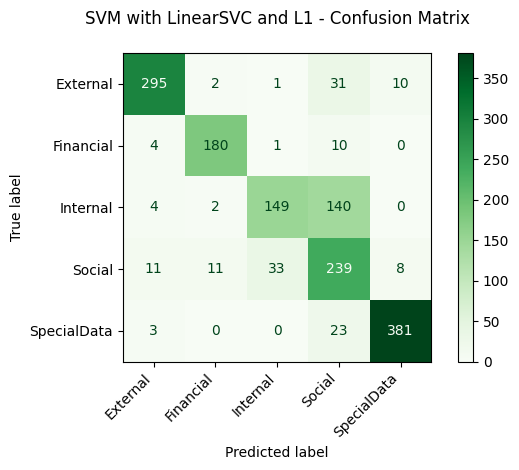

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
import numpy as np

# Try both L1 and L2 regularization
param_grid_linear = {
    'C': np.logspace(-4, 4, 10),
    'penalty': ['l1', 'l2'],     # Try both regularization types
    'dual': [False]               # L1 requires dual=False
}

linear_svm = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid_linear,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Fitting Linear SVM...")
linear_svm.fit(X_train, y_train)

print(f"\nBest Parameters: {linear_svm.best_params_}")
print(f"Best C: {linear_svm.best_params_['C']:.4f}")
print(f"Best Penalty: {linear_svm.best_params_['penalty']}")
print(f"Best CV F1: {linear_svm.best_score_:.4f}")

y_pred_linear = linear_svm.predict(X_test)
print(f"Test F1: {f1_score(y_test, y_pred_linear, average='macro'):.4f}")

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title(f"SVM with LinearSVC and L1 - Confusion Matrix\n")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
def evaluate(name, y_true, y_pred, y_prob=None):
    results = {
        'model':        name,
        'accuracy':     round(accuracy_score(y_true, y_pred) * 100, 2),
        'f1_macro':     round(f1_score(y_true, y_pred, average='macro') * 100, 2),
        'f1_weighted':  round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
        'f1_sensitive': round(f1_score(y_true, y_pred, pos_label=1) * 100, 2),
        'auc':          round(roc_auc_score(y_true, y_prob) * 100, 2)
                        if y_prob is not None else None
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:     {results['accuracy']}%")
    print(f"  Macro F1:     {results['f1_macro']}%")
    print(f"  Weighted F1:  {results['f1_weighted']}%")
    print(f"  F1 Sensitive: {results['f1_sensitive']}%")
    if results['auc']:
        print(f"  AUC-ROC:      {results['auc']}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Non-sensitive','Sensitive'])}")
    return results

all_results = []

**TRANSFORMER MODELS**

1. RoBERTa

In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import (AutoTokenizer,
                           AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# First, create DataFrames from your existing splits
# Reconstruct the original combined_df with text and labels
combined_df_with_text = pd.DataFrame({
    'text': X.tolist(),  # X contains the text
    'label_encoded': y.tolist()  # y contains the encoded labels
})

# Split into train/val/test
# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    combined_df_with_text,
    test_size=0.3,
    random_state=42,
    stratify=combined_df_with_text['label_encoded']
)

# Second split: split temp into 50% val, 50% test (15% each of total)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label_encoded']
)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Get number of classes
num_classes = len(le.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {le.classes_}")

def make_hf_dataset(df, tokenizer, max_length=256):
    ds = Dataset.from_dict({
        'text':  df['text'].tolist(),
        'label': df['label_encoded'].tolist()
    })
    def tokenize(batch):
        return tokenizer(batch['text'],
                         truncation=True,
                         padding='max_length',
                         max_length=max_length)
    return ds.map(tokenize, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds) * 100, 2),
        'f1_macro': round(f1_score(labels, preds, average='macro',
                          zero_division=0) * 100, 2)
    }

TRANSFORMER_MODELS = {
    'RoBERTa-base': 'roberta-base',
    'DeBERTa-base': 'microsoft/deberta-base',
    'DistilBERT':   'distilbert-base-uncased'  # Faster alternative
}

for model_name, model_path in TRANSFORMER_MODELS.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(
                    model_path, num_labels=num_classes)  # Changed to multiclass

    train_ds = make_hf_dataset(train_df, tokenizer)
    val_ds   = make_hf_dataset(val_df,   tokenizer)
    test_ds  = make_hf_dataset(test_df,  tokenizer)

    args = TrainingArguments(
        output_dir                  = f'./results/{model_name}',
        learning_rate               = 2e-5,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size  = 16,
        num_train_epochs            = 3,
        weight_decay                = 0.01,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_macro',
        logging_steps               = 50,
        seed                        = 42,
        report_to                   = 'none'  # Disable wandb if not needed
    )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics
    )

    trainer.train()

    # Predict on test set
    preds_output = trainer.predict(test_ds)
    logits       = preds_output.predictions
    y_pred       = np.argmax(logits, axis=-1)

    # Get p

Train size: 3587
Val size: 769
Test size: 769

Number of classes: 5
Classes: ['External' 'Financial' 'Internal' 'Social' 'SpecialData']

Training RoBERTa-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/3587 [00:00<?, ? examples/s]

Map:   0%|          | 0/769 [00:00<?, ? examples/s]

Map:   0%|          | 0/769 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
from transformers import TrainingArguments, Trainer, AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import torch
from sklearn.metrics import f1_score

# Define hyperparameter grid
hyperparameter_grid = {
    'learning_rate': [1e-5, 2e-5, 3e-5],
    'batch_size': [8, 16],
    'num_epochs': [3, 4, 5],
    'weight_decay': [0.01, 0.1]
}

best_f1 = 0
best_params = {}
all_trial_results = []

# Try all combinations
from itertools import product

combinations = list(product(
    hyperparameter_grid['learning_rate'],
    hyperparameter_grid['batch_size'],
    hyperparameter_grid['num_epochs'],
    hyperparameter_grid['weight_decay']
))

print(f"Testing {len(combinations)} hyperparameter combinations...\n")

for i, (lr, batch_size, epochs, weight_decay) in enumerate(combinations):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{len(combinations)}")
    print(f"LR: {lr}, Batch: {batch_size}, Epochs: {epochs}, Weight Decay: {weight_decay}")
    print(f"{'='*60}")

    # Load model
    tokenizer = AutoTokenizer.from_pretrained('roberta-base')
    model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=num_classes)

    # Prepare da